In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from google.colab import userdata
your_key = userdata.get('PIE_Colab')

# Configuration

sns.set_palette("husl")

In [ ]:
!git clone https://{your_key}@github.com/william94000schr/ATR_SAR.git

Cloning into 'ATR_SAR'...
remote: Enumerating objects: 615, done.
remote: Counting objects: 100% (157/157), done.
remote: Compressing objects: 100% (107/107), done.
remote: Total 615 (delta 88), reused 113 (delta 47), pack-reused 458 (from 1)
Receiving objects: 100% (615/615), 3.22 MiB | 8.95 MiB/s, done.
Resolving deltas: 100% (356/356), done.


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
#!cp /content/drive/MyDrive/PIE/FasterRCNN_ResNet_SOC50_results/train_results.json /content/ATR_SAR/outputs/
#!cp /content/drive/MyDrive/PIE/FasterRCNN_ResNet_SOC50_results/test_results.json /content/ATR_SAR/outputs/
!cp /content/drive/MyDrive/PIE/SOC17classes_1_5sur5/test_results.json /content/ATR_SAR/outputs/
!cp /content/drive/MyDrive/PIE/SOC17classes_1_5sur5/train_results.json /content/ATR_SAR/outputs/


In [ ]:
%cd /content/ATR_SAR/

/content/ATR_SAR


In [ ]:
with open('outputs/train_results.json', 'r') as f:
    train_results = json.load(f)

with open('outputs/test_results.json', 'r') as f:
    test_results = json.load(f)

print("Donnees chargees avec succes")
print(f"Nombre d'epochs d'entrainement: {len(train_results)}")
print(f"Nombre d'images de test: {len(test_results['detailed_results'])}")

Donnees chargees avec succes
Nombre d'epochs d'entrainement: 15
Nombre d'images de test: 29284


In [ ]:
metrics = test_results['global_metrics']
class_names = test_results['class_names']

In [ ]:
print("\n" + "="*60)
print("PERFORMANCES GLOBALES")
print("="*60)
print(f"mAP: {metrics['map']:.4f}")
print(f"mAP@50: {metrics['map_50']:.4f}")
print(f"mAP@75: {metrics['map_75']:.4f}")
print(f"mAR (mean Average Recall): {metrics['mar_100']:.4f}")


PERFORMANCES GLOBALES
mAP: 0.5434
mAP@50: 0.9352
mAP@75: 0.5713
mAR (mean Average Recall): 0.6352


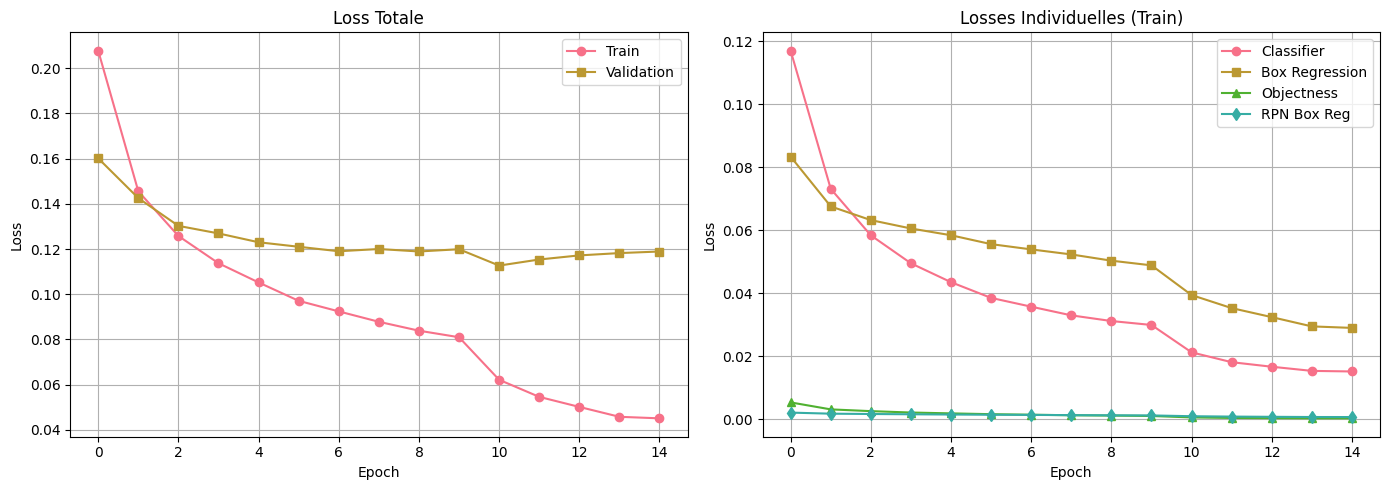

In [ ]:
epochs = [r['epoch'] for r in train_results]
train_losses = [r['train']['loss_total'] for r in train_results]
val_losses = [r['val']['loss_total'] for r in train_results]

train_cls = [r['train']['loss_classifier'] for r in train_results]
train_box = [r['train']['loss_box_reg'] for r in train_results]
train_obj = [r['train']['loss_objectness'] for r in train_results]
train_rpn = [r['train']['loss_rpn_box_reg'] for r in train_results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss totale
axes[0].plot(epochs, train_losses, label='Train', marker='o')
axes[0].plot(epochs, val_losses, label='Validation', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Totale')
axes[0].legend()
axes[0].grid(True)

# Losses individuelles (train)
axes[1].plot(epochs, train_cls, label='Classifier', marker='o')
axes[1].plot(epochs, train_box, label='Box Regression', marker='s')
axes[1].plot(epochs, train_obj, label='Objectness', marker='^')
axes[1].plot(epochs, train_rpn, label='RPN Box Reg', marker='d')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Losses Individuelles (Train)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('losses_curves.png', dpi=150, bbox_inches='tight')
plt.show()


PERFORMANCES PAR CLASSE
Classe                     AP       AR
----------------------------------------------------------------------
Mini Car               0.4554   0.5501
Car                    0.4712   0.5850
SUV                    0.4826   0.5872
Small Bus              0.4638   0.5730
Medium Bus             0.5191   0.6179
Large Bus              0.6361   0.7145
Pickup+Light DT        0.5186   0.6092
Heavy DT               0.6235   0.7042
Heavy ST               0.6523   0.7283
Light PV               0.4767   0.5726
Heavy FT               0.7159   0.7806
Medium TT              0.5783   0.6639
Mixer Truck            0.6487   0.7241
Forklift               0.4181   0.5220
Ambulance              0.4991   0.6006
ECV                    0.5107   0.6120
Construction           0.5682   0.6539


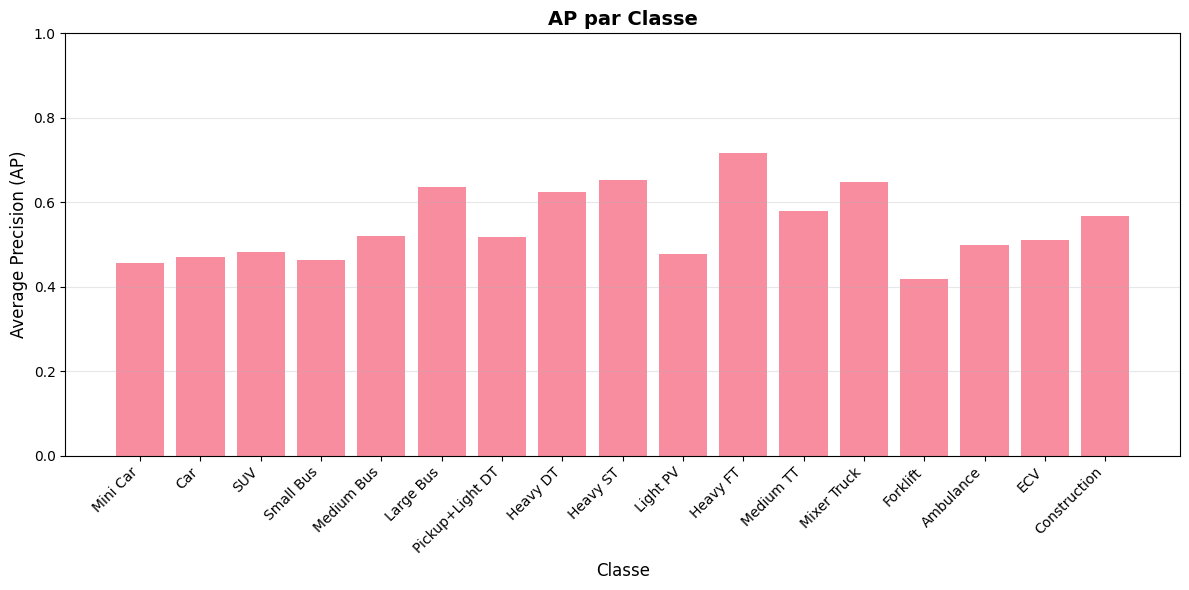

In [ ]:
map_per_class = metrics['map_per_class']
mar_per_class = metrics['mar_100_per_class']
num_classes = len(map_per_class)

class_labels = []
for i in range(num_classes):
    # Ajuster l'indexation selon votre mapping
    # Si PyTorch label i correspond à COCO category_id i+1 :
    coco_id = str(i + 1)  # Les clés JSON sont des strings
    class_name = class_names.get(coco_id, f"Class_{i}")
    class_labels.append(class_name)

# Tableau récapitulatif
print("\n" + "="*70)
print("PERFORMANCES PAR CLASSE")
print("="*70)
print(f"{'Classe':<20} {'AP':>8} {'AR':>8}")
print("-"*70)
for i in range(num_classes):
    print(f"{class_labels[i]:<20} {map_per_class[i]:>8.4f} {mar_per_class[i]:>8.4f}")

# Bar plot AP par classe
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(num_classes)
ax.bar(x_pos, map_per_class, alpha=0.8)
ax.set_xlabel('Classe', fontsize=12)
ax.set_ylabel('Average Precision (AP)', fontsize=12)
ax.set_title('AP par Classe', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(class_labels, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1])  # AP est entre 0 et 1
plt.tight_layout()
plt.savefig('ap_per_class.png', dpi=150, bbox_inches='tight')
plt.show()



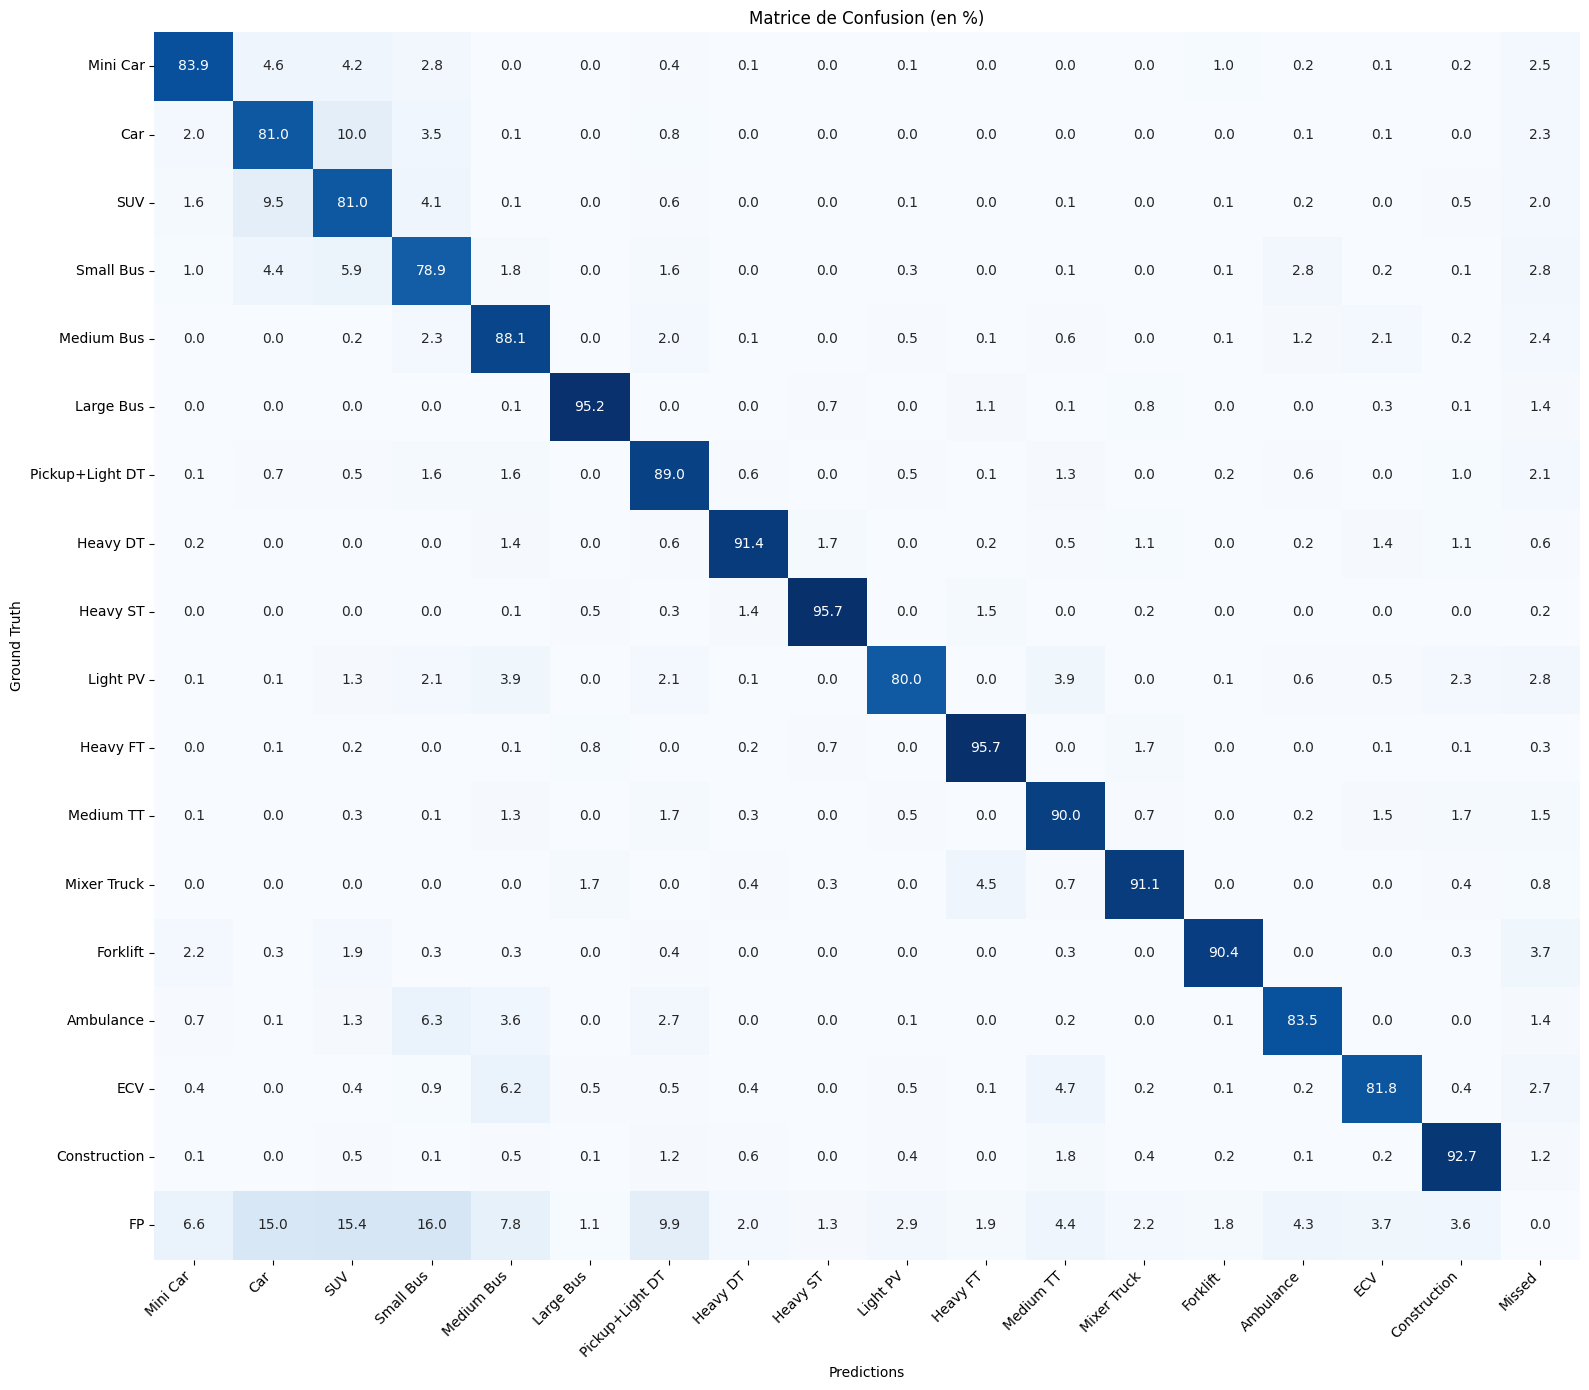

In [ ]:
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - inter

    return inter / union if union > 0 else 0

# Initialisation de la matrice (classes + Missed)
confusion_matrix = np.zeros((num_classes + 1, num_classes + 1), dtype=int)
# Derniere ligne pour FP, derniere colonne pour Missed

for result in test_results['detailed_results']:
    gt_boxes = result['ground_truth']['boxes']
    gt_labels = result['ground_truth']['labels']
    pred_boxes = result['predictions']['boxes']
    pred_labels = result['predictions']['labels']
    pred_scores = result['predictions']['scores']

    matched_preds = set()

    # Pour chaque GT, trouver la meilleure prediction
    for gt_idx, (gt_box, gt_label) in enumerate(zip(gt_boxes, gt_labels)):
        best_iou = 0
        best_pred_idx = -1

        for pred_idx, pred_box in enumerate(pred_boxes):
            if pred_idx in matched_preds:
                continue
            iou = compute_iou(gt_box, pred_box)
            if iou > best_iou:
                best_iou = iou
                best_pred_idx = pred_idx

        if best_iou > 0.5 and best_pred_idx != -1:
            pred_label = pred_labels[best_pred_idx]
            confusion_matrix[gt_label - 1][pred_label - 1] += 1
            matched_preds.add(best_pred_idx)
        else:
            # Non detecte -> colonne "Missed"
            confusion_matrix[gt_label - 1][num_classes] += 1

    # Predictions non appariees = FP (derniere ligne)
    for pred_idx in range(len(pred_boxes)):
        if pred_idx not in matched_preds:
            pred_label = pred_labels[pred_idx]
            confusion_matrix[num_classes][pred_label - 1] += 1

# Conversion en pourcentages par ligne
confusion_matrix_pct = np.zeros_like(confusion_matrix, dtype=float)
for i in range(confusion_matrix.shape[0]):
    row_sum = confusion_matrix[i].sum()
    if row_sum > 0:
        confusion_matrix_pct[i] = (confusion_matrix[i] / row_sum) * 100

class_labels = []
for i in range(num_classes):
    # On récupère le nom depuis le dictionnaire class_names
    # coco_id est souvent i+1 (si tes classes commencent à 1 dans le dataset)
    coco_id = str(i+1)
    class_name = class_names.get(coco_id, f"Class_{i}")
    class_labels.append(class_name)

# Affichage
labels_x = class_labels + ["Missed"] # Pour l'axe horizontal
labels_y = class_labels + ["FP"]

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(confusion_matrix_pct,
            annot=True,
            fmt='.1f',
            cmap='Blues',
            xticklabels=labels_x,
            yticklabels=labels_y,
            cbar = False,
            #cbar_kws={'label': 'Pourcentage (%)'},
            ax=ax)
ax.set_xlabel('Predictions')
ax.set_ylabel('Ground Truth')
ax.set_title('Matrice de Confusion (en %)')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
